# CreditWise Loan Approval Prediction
## 1. Imports and Setup
Importing necessary libraries for data manipulation, visualization, and machine learning pipelines.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)

## 2. Data Loading
Loading the `loan_approval_data.csv` dataset. Includes fallback logic to upload directly via Google Colab if the file is not found locally.


In [ ]:
import pandas as pd
from google.colab import files
import os

DATA_PATH = "/content/loan_approval_data.csv"

# Check if the file exists, if not, prompt user to upload
if not os.path.exists(DATA_PATH):
    print("File not found. Please upload 'loan_approval_data.csv'.")
    uploaded = files.upload()
    if "loan_approval_data.csv" in uploaded:
        print("File uploaded successfully.")
    else:
        raise FileNotFoundError("loan_approval_data.csv was not uploaded.")

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print("Columns:")
print(df.columns.tolist())
df.head()

Dataset shape: (10000, 20)
Columns:
['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age', 'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved']


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [ ]:
possible_targets = [
    "Loan_Approved", "Loan Approved", "loan_approved", "loan approved",
    "LoanApproved", "loanapproved"
]

def normalize_name(col):
    return col.strip().lower().replace(" ", "_")

normalized_map = {normalize_name(c): c for c in df.columns}

target_col = None
for t in possible_targets:
    key = normalize_name(t)
    if key in normalized_map:
        target_col = normalized_map[key]
        break

if target_col is None:
    raise ValueError("Target column not found. Please rename target to Loan_Approved.")

print(f"Detected target column: {target_col}")

Detected target column: Loan_Approved


## 3. Data Cleaning
### 3.1 Identifying Missing Values
Calculating the total count of missing values per column. Imputation will be deferred to the Scikit-Learn pipeline to prevent data leakage.


In [ ]:
missing_per_col = df.isna().sum().sort_values(ascending=False)
missing_total = int(df.isna().sum().sum())

print("Missing values per column:")
display(missing_per_col[missing_per_col > 0])
print(f"\nTotal missing values in dataset: {missing_total}")

Missing values per column:


,0
Credit_Score,562
DTI_Ratio,548
Loan_Purpose,543
Loan_Term,534
Marital_Status,525
Applicant_Income,520
Collateral_Value,517
Education_Level,509
Gender,503
Property_Area,500



Total missing values in dataset: 9262


In [ ]:
# Keep full data; impute missing values later inside preprocessing to avoid leakage.
# Drop duplicate rows as a safe cleaning step.

df_clean = df.drop_duplicates().copy()
print(f"Rows before cleaning: {len(df)}")
print(f"Rows after duplicate removal: {len(df_clean)}")
print("\nData types after cleaning:")
display(df_clean.dtypes.to_frame("dtype"))

Rows before cleaning: 10000
Rows after duplicate removal: 10000

Data types after cleaning:


,dtype
Applicant_ID,float64
Applicant_Income,float64
Coapplicant_Income,float64
Employment_Status,object
Age,float64
Marital_Status,object
Dependents,float64
Credit_Score,float64
Existing_Loans,float64
DTI_Ratio,float64


## 4. Exploratory Data Analysis (EDA)
### 4.1 Class Distribution
Visualizing the balance of the target variable (`Loan_Approved`). This helps determine if accuracy is an appropriate metric or if F1-score is required due to imbalance.


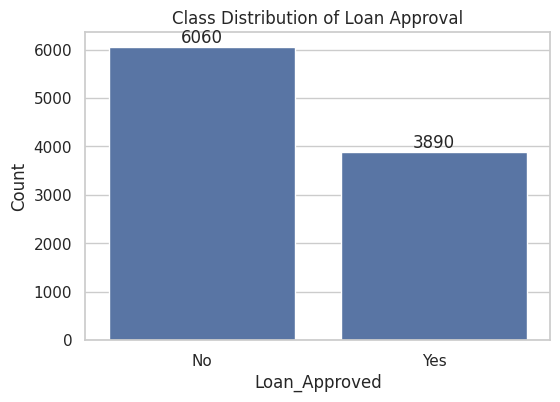

Class ratio:
Loan_Approved
No     0.609045
Yes    0.390955
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=df_clean[target_col])
plt.title("Class Distribution of Loan Approval")
plt.xlabel(target_col)
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

class_ratio = df_clean[target_col].value_counts(normalize=True)
print("Class ratio:")
print(class_ratio)

### 4.2 Outlier Detection
Using boxplots across numerical features to identify extreme outliers.


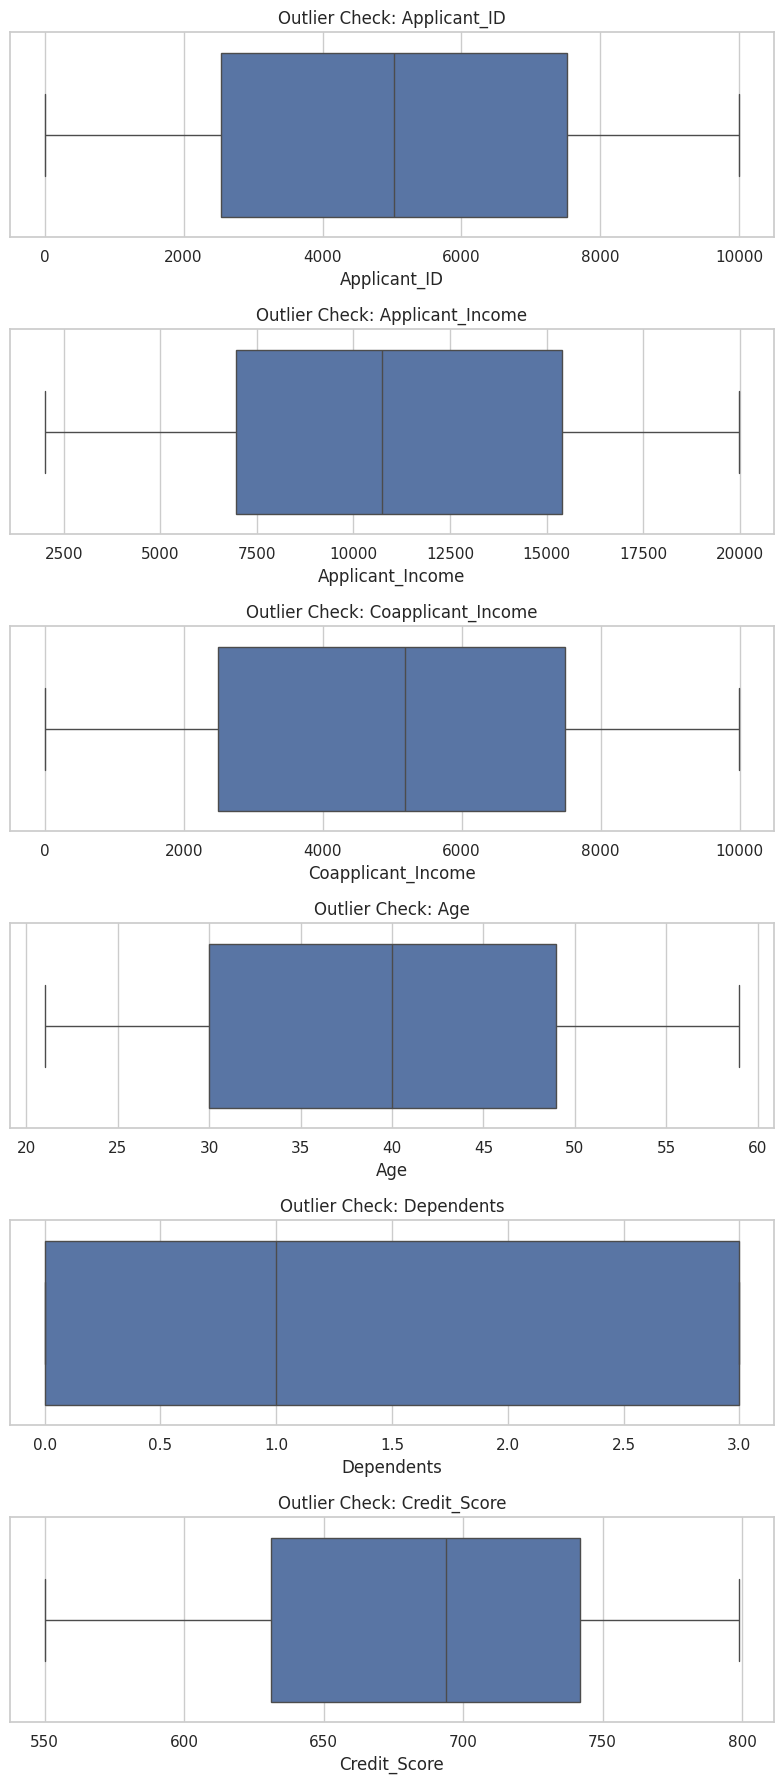

In [ ]:
import numpy as np

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
feature_numeric_cols = [c for c in numeric_cols if c != target_col]

if feature_numeric_cols:
    sample_cols = feature_numeric_cols[:6]
    fig, axes = plt.subplots(len(sample_cols), 1, figsize=(8, 3 * len(sample_cols)))
    if len(sample_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, sample_cols):
        sns.boxplot(x=df_clean[col], ax=ax)
        ax.set_title(f"Outlier Check: {col}")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric feature columns found for outlier checks.")

### 4.3 Credit Score vs Loan Approval
Generating a histogram to observe the relationship between an applicant's credit score and their final loan outcome.


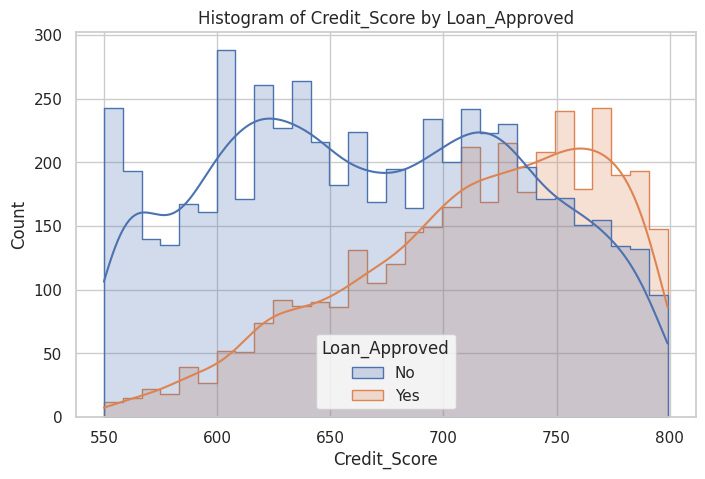

In [ ]:
credit_score_candidates = ["Credit_Score", "Credit Score", "credit_score", "credit score"]
credit_col = None
for c in credit_score_candidates:
    key = normalize_name(c)
    for col in df_clean.columns:
        if normalize_name(col) == key:
            credit_col = col
            break
    if credit_col is not None:
        break

if credit_col is not None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_clean, x=credit_col, hue=target_col, bins=30, kde=True, element="step")
    plt.title(f"Histogram of {credit_col} by {target_col}")
    plt.show()
else:
    print("Credit score column not found; skipping Credit Score histogram.")

## 5. Train/Test Split
Splitting the dataset 80/20 using stratified sampling to ensure both sets maintain the same class ratio. This is performed **before** any transformations to completely prevent data leakage. Rows missing the target label are dropped.


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

X = df_clean.drop(columns=[target_col]).copy()
y = df_clean[target_col].copy()

# Handle potential NaNs in the target variable
if y.isnull().any():
    print(f"Warning: Target variable '{target_col}' contains NaN values. Dropping {y.isnull().sum()} rows with NaN target.")
    valid_indices = y.dropna().index
    X = X.loc[valid_indices]
    y = y.loc[valid_indices]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric features:", len(num_features))
print("Categorical features:", len(cat_features))

Train shape: (7960, 19)
Test shape: (1990, 19)
Numeric features: 12
Categorical features: 7


## 6. Preprocessing Pipelines
Creating Scikit-Learn `ColumnTransformer` pipelines.
- **Categorical features:** Imputed with the mode and encoded via `OneHotEncoder`.
- **Numerical features:** Imputed with the median (robust to outliers). Distance/Gradient models receive a `StandardScaler`, while Tree-based models remain unscaled.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Scaling is used for Logistic Regression; tree models do not require scaling.
preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, num_features),
    ("cat", categorical_transformer, cat_features)
])

preprocessor_unscaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_unscaled, num_features),
    ("cat", categorical_transformer, cat_features)
])

## 7. Correlation & Multicollinearity
Visualizing the correlation matrix to identify redundant numerical features. Pairs with `|r| >= 0.85` will be flagged.


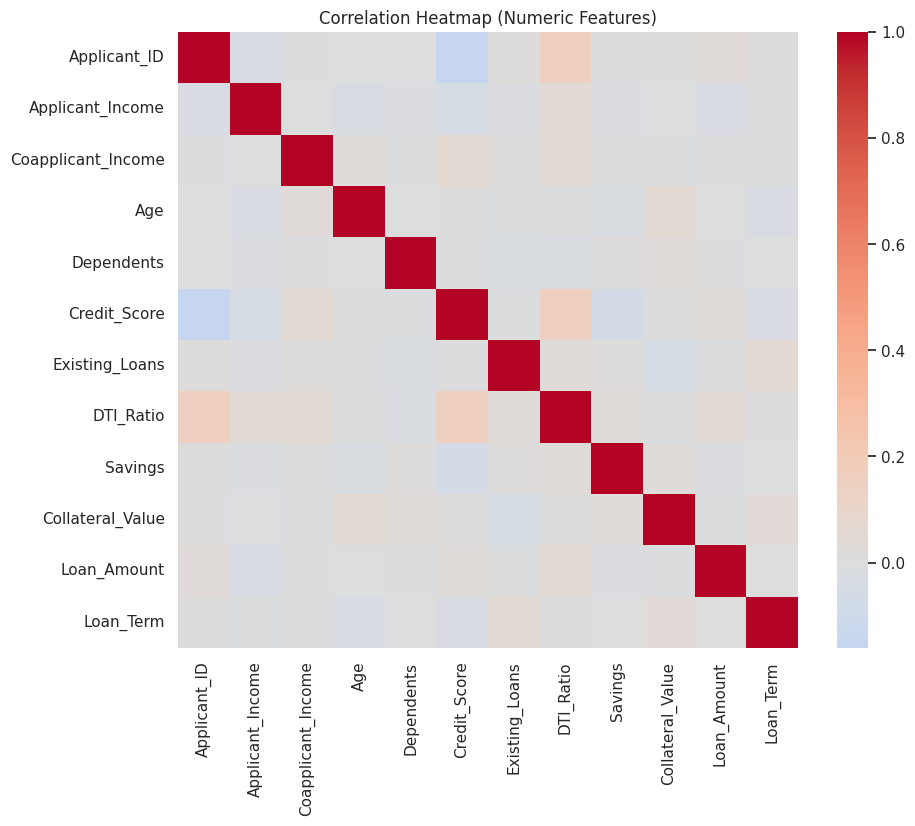

Highly correlated pairs (|r| >= 0.85):
None


In [ ]:
if len(feature_numeric_cols) >= 2:
    corr = df_clean[feature_numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.show()

    threshold = 0.85
    high_pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            val = corr.iloc[i, j]
            if abs(val) >= threshold:
                high_pairs.append((cols[i], cols[j], val))

    print(f"Highly correlated pairs (|r| >= {threshold}):")
    if high_pairs:
        for a, b, v in high_pairs:
            print(f"- {a} vs {b}: {v:.3f}")
    else:
        print("None")
else:
    print("Not enough numeric features for correlation analysis.")

### 7.1 Corrective Step
Dropping one feature from each highly correlated pair to resolve multicollinearity before training.


In [ ]:
# Optional corrective step: drop one feature from each highly correlated pair.
drop_corr_cols = set()
if 'high_pairs' in globals() and high_pairs:
    for a, b, _ in high_pairs:
        drop_corr_cols.add(b)

X_reduced = X.drop(columns=list(drop_corr_cols), errors="ignore")
num_features_reduced = X_reduced.select_dtypes(include=[np.number]).columns.tolist()
cat_features_reduced = X_reduced.select_dtypes(exclude=[np.number]).columns.tolist()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

print("Dropped correlated columns:", list(drop_corr_cols))
print("Reduced train shape:", X_train_r.shape)

Dropped correlated columns: []
Reduced train shape: (7960, 19)


## 8. Model Training & Evaluation
Training 6 distinct models utilizing our safe pipelines. Evaluated primarily on **F1-score** due to the dataset's class imbalance.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

numeric_transformer_scaled_r = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_unscaled_r = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_r = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled_r = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled_r, num_features_reduced),
    ("cat", categorical_transformer_r, cat_features_reduced)
])

preprocessor_unscaled_r = ColumnTransformer(transformers=[
    ("num", numeric_transformer_unscaled_r, num_features_reduced),
    ("cat", categorical_transformer_r, cat_features_reduced)
])

# Encode target variable to 0/1
le = LabelEncoder()
y_train_r_encoded = le.fit_transform(y_train_r)
y_test_r_encoded = le.transform(y_test_r)

# Ensure 'Yes' maps to 1, 'No' maps to 0 for consistent positive label
if 'Yes' in le.classes_ and le.transform(['Yes'])[0] == 0:
    # If 'Yes' mapped to 0, invert the encoding
    y_train_r_encoded = 1 - y_train_r_encoded
    y_test_r_encoded = 1 - y_test_r_encoded

models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled_r),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_unscaled_r),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor_unscaled_r),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    "MLP": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled_r),
        ("model", MLPClassifier(random_state=42, max_iter=1000))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled_r),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "AdaBoost": Pipeline(steps=[
        ("preprocessor", preprocessor_unscaled_r),
        ("model", AdaBoostClassifier(random_state=42))
    ])
}

results = []
predictions = {}

for name, pipe in models.items():
    pipe.fit(X_train_r, y_train_r_encoded)
    y_pred = pipe.predict(X_test_r)
    predictions[name] = y_pred

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_r_encoded, y_pred),
        "Precision": precision_score(y_test_r_encoded, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_test_r_encoded, y_pred, pos_label=1, zero_division=0),
        "F1": f1_score(y_test_r_encoded, y_pred, pos_label=1, zero_division=0)
    }
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1
0,Gradient Boosting,0.703518,0.630919,0.582262,0.605615
1,AdaBoost,0.703015,0.631505,0.577121,0.603089
2,Logistic Regression,0.707538,0.643695,0.564267,0.601370
3,Random Forest,0.690452,0.636824,0.484576,0.550365
4,MLP,0.646231,0.550964,0.514139,0.531915
5,KNN,0.643216,0.547486,0.503856,0.524766


### 8.1 Confusion Matrices
Plotting heatmaps to visualize True Positives, False Positives, True Negatives, and False Negatives for each model.


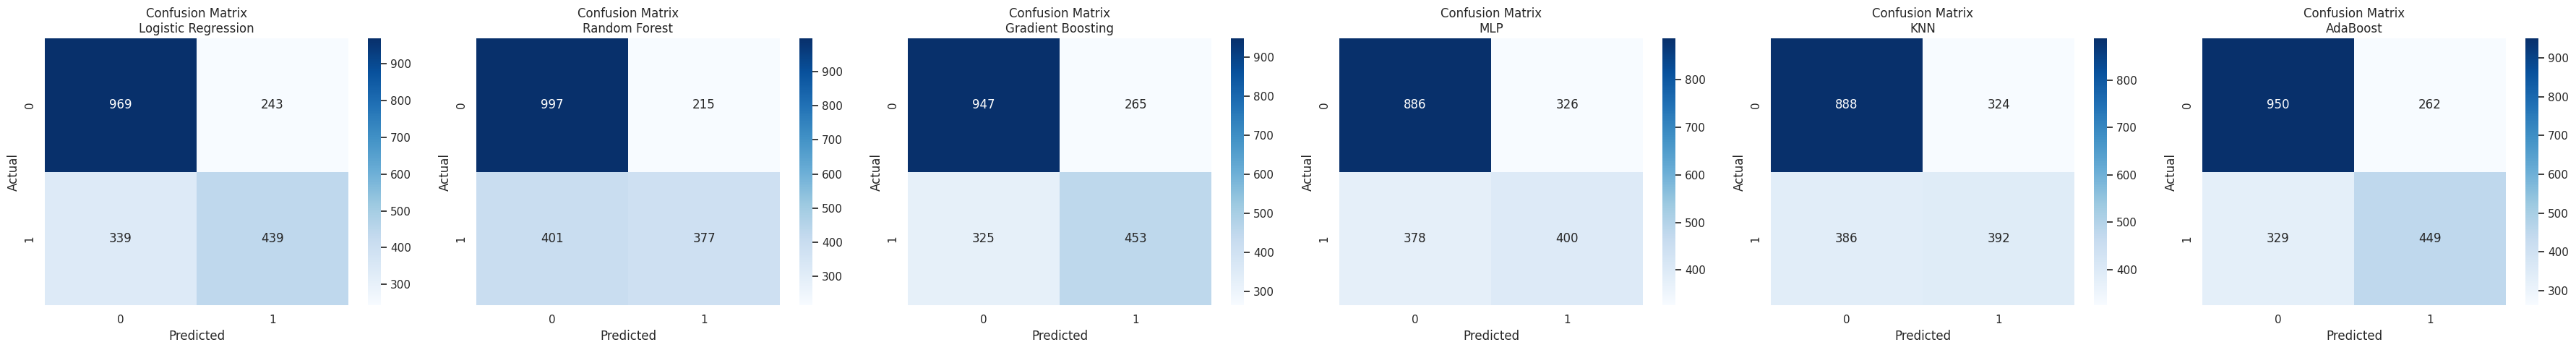


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      1212
           1       0.64      0.56      0.60       778

    accuracy                           0.71      1990
   macro avg       0.69      0.68      0.69      1990
weighted avg       0.70      0.71      0.70      1990


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.82      0.76      1212
           1       0.64      0.48      0.55       778

    accuracy                           0.69      1990
   macro avg       0.67      0.65      0.66      1990
weighted avg       0.68      0.69      0.68      1990


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      1212
           1       0.63      0.58      0.61       778

    accuracy                           0.70      1990
   m

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test_r_encoded, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix\n{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

for name, y_pred in predictions.items():
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test_r_encoded, y_pred, zero_division=0))

## 9. Feature Engineering
Creating a pairwise ratio feature to test if engineered relationships improve the baseline F1-score.


In [ ]:
X_fe = X_reduced.copy()

# Example feature engineering for numeric features: add pairwise ratio if possible.
if len(num_features_reduced) >= 2:
    a, b = num_features_reduced[0], num_features_reduced[1]
    X_fe[f"{a}_to_{b}_ratio"] = X_fe[a] / (X_fe[b].abs() + 1e-6)
    print(f"Created engineered feature: {a}_to_{b}_ratio")
else:
    print("Not enough numeric columns for ratio feature engineering.")

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

num_features_fe = X_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_features_fe = X_fe.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor_fe = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_features_fe),
    ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_features_fe)
])

fe_model = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Encode target variable to 0/1 for the feature-engineered model
y_train_fe_encoded = le.transform(y_train_fe)
y_test_fe_encoded = le.transform(y_test_fe)

fe_model.fit(X_train_fe, y_train_fe_encoded)
y_pred_fe_encoded = fe_model.predict(X_test_fe)

fe_f1 = f1_score(y_test_fe_encoded, y_pred_fe_encoded, zero_division=0)
base_best_f1 = results_df["F1"].max()

comparison_df = pd.DataFrame([
    {"Setting": "Best baseline model", "F1": base_best_f1},
    {"Setting": "Feature engineered (LogReg)", "F1": fe_f1}
])

display(comparison_df)
print("F1 improvement:", fe_f1 - base_best_f1)


Created engineered feature: Applicant_ID_to_Applicant_Income_ratio


,Setting,F1
0,Best baseline model,0.605615
1,Feature engineered (LogReg),0.598220


F1 improvement: -0.007394576273667908


## 10. Best Model Justification
Automatically selecting the highest-scoring model based on the F1 metric and formatting a justification template.


In [ ]:
best_row = results_df.sort_values("F1", ascending=False).iloc[0]
print("Best model based on F1-score:")
print(best_row)

print("\nJustification template:")
print(
    f"Selected model: {best_row['Model']} | "
    f"F1={best_row['F1']:.4f}, Precision={best_row['Precision']:.4f}, Recall={best_row['Recall']:.4f}. "
    "This model is chosen primarily for highest F1-score while maintaining a useful precision-recall balance."
)

Best model based on F1-score:
Model        Gradient Boosting
Accuracy              0.703518
Precision             0.630919
Recall                0.582262
F1                    0.605615
Name: 0, dtype: object

Justification template:
Selected model: Gradient Boosting | F1=0.6056, Precision=0.6309, Recall=0.5823. This model is chosen primarily for highest F1-score while maintaining a useful precision-recall balance.
